In [14]:
# ============================================================
# BEIJING AIR QUALITY PROJECT
# OFFICIAL UCI DATASET
# DATA LOADING + CLEANING + EDA
# ============================================================

!pip install -q pandas numpy matplotlib seaborn plotly


# ------------------------------------------------------------
# IMPORT LIBRARIES
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
# ------------------------------------------------------------
# DOWNLOAD DATASET FROM GITHUB MIRROR
# ------------------------------------------------------------

# ------------------------------------------------------------
# DOWNLOAD THE 12 CSV FILES DIRECTLY
# ------------------------------------------------------------

import pandas as pd
import requests
from io import StringIO

base_url = "https://raw.githubusercontent.com/fearlab/Datasets/master/"

stations = [
    "Aotizhongxin",
    "Changping",
    "Dingling",
    "Dongsi",
    "Guanyuan",
    "Gucheng",
    "Huairou",
    "Nongzhanguan",
    "Shunyi",
    "Tiantan",
    "Wanliu",
    "Wanshouxigong"
]

dataframes = []

for station in stations:

    filename = (
        f"PRSA_Data_{station}_20130301-20170228.csv"
    )

    url = base_url + filename

    print("Downloading:", station)

    response = requests.get(
        url,
        timeout=60
    )

    print(
        "Status:",
        response.status_code,
        "| Size:",
        len(response.content)
    )

    if response.status_code != 200:
        raise Exception(
            f"Could not download {filename}"
        )

    temp_df = pd.read_csv(
        StringIO(
            response.text
        )
    )

    dataframes.append(
        temp_df
    )


# ------------------------------------------------------------
# COMBINE ALL 12 STATIONS
# ------------------------------------------------------------

df = pd.concat(
    dataframes,
    ignore_index=True
)

print("\nAll station files loaded successfully!")

print(
    "Rows:",
    df.shape[0]
)

print(
    "Columns:",
    df.shape[1]
)

print(
    "Stations:",
    df["station"].nunique()
)



Downloading: Aotizhongxin
Status: 200 | Size: 2835916
Downloading: Changping
Status: 200 | Size: 2722295
Downloading: Dingling
Status: 200 | Size: 2675856
Downloading: Dongsi
Status: 200 | Size: 2636684
Downloading: Guanyuan
Status: 200 | Size: 2695860
Downloading: Gucheng
Status: 200 | Size: 2654625
Downloading: Huairou
Status: 200 | Size: 2641027
Downloading: Nongzhanguan
Status: 200 | Size: 2839705
Downloading: Shunyi
Status: 200 | Size: 2620654
Downloading: Tiantan
Status: 200 | Size: 2655061
Downloading: Wanliu
Status: 200 | Size: 2659544
Downloading: Wanshouxigong
Status: 200 | Size: 2871076

All station files loaded successfully!
Rows: 420768
Columns: 18
Stations: 12



DATASET OVERVIEW
Rows: 420768
Columns: 18

Columns:
['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']

FIRST FIVE ROWS


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin



DATA TYPES
No           int64
year         int64
month        int64
day          int64
hour         int64
PM2.5      float64
PM10       float64
SO2        float64
NO2        float64
CO         float64
O3         float64
TEMP       float64
PRES       float64
DEWP       float64
RAIN       float64
wd          object
WSPM       float64
station     object
dtype: object

DUPLICATES
Duplicate rows: 0

MISSING VALUES
CO       20701
O3       13277
NO2      12116
SO2       9021
PM2.5     8739
PM10      6449
wd        1822
DEWP       403
TEMP       398
PRES       393
RAIN       390
WSPM       318
dtype: int64

NEGATIVE VALUES
PM2.5 : 0
PM10 : 0
SO2 : 0
NO2 : 0
CO : 0
O3 : 0
RAIN : 0
WSPM : 0

MISSING VALUES AFTER CLEANING
Series([], dtype: int64)

FINAL DATASET
Rows: 420768
Columns: 22

Number of stations:
12
['Aotizhongxin' 'Changping' 'Dingling' 'Dongsi' 'Guanyuan' 'Gucheng'
 'Huairou' 'Nongzhanguan' 'Shunyi' 'Tiantan' 'Wanliu' 'Wanshouxigong']

Date range:
2013-03-01 00:00:00
2017-02-28 23:00

,PM2.5,PM10,SO2,NO2,CO,O3
station,,,,,,
Aotizhongxin,82.12,109.59,17.15,59.12,1244.56,55.65
Changping,70.55,94.28,14.82,44.03,1137.02,57.73
Dingling,65.43,83.30,11.61,27.28,887.40,68.29
Dongsi,85.66,109.95,18.37,53.39,1299.97,56.96
Guanyuan,82.51,108.78,17.46,57.77,1252.73,55.30
Gucheng,83.41,118.65,15.25,55.76,1307.03,57.43
Huairou,69.01,90.98,11.89,32.15,1013.53,59.47
Nongzhanguan,84.38,108.69,18.57,57.96,1309.75,58.34
Shunyi,78.85,98.40,13.26,43.64,1163.02,54.68


/tmp/ipykernel_1627/171196098.py:375: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


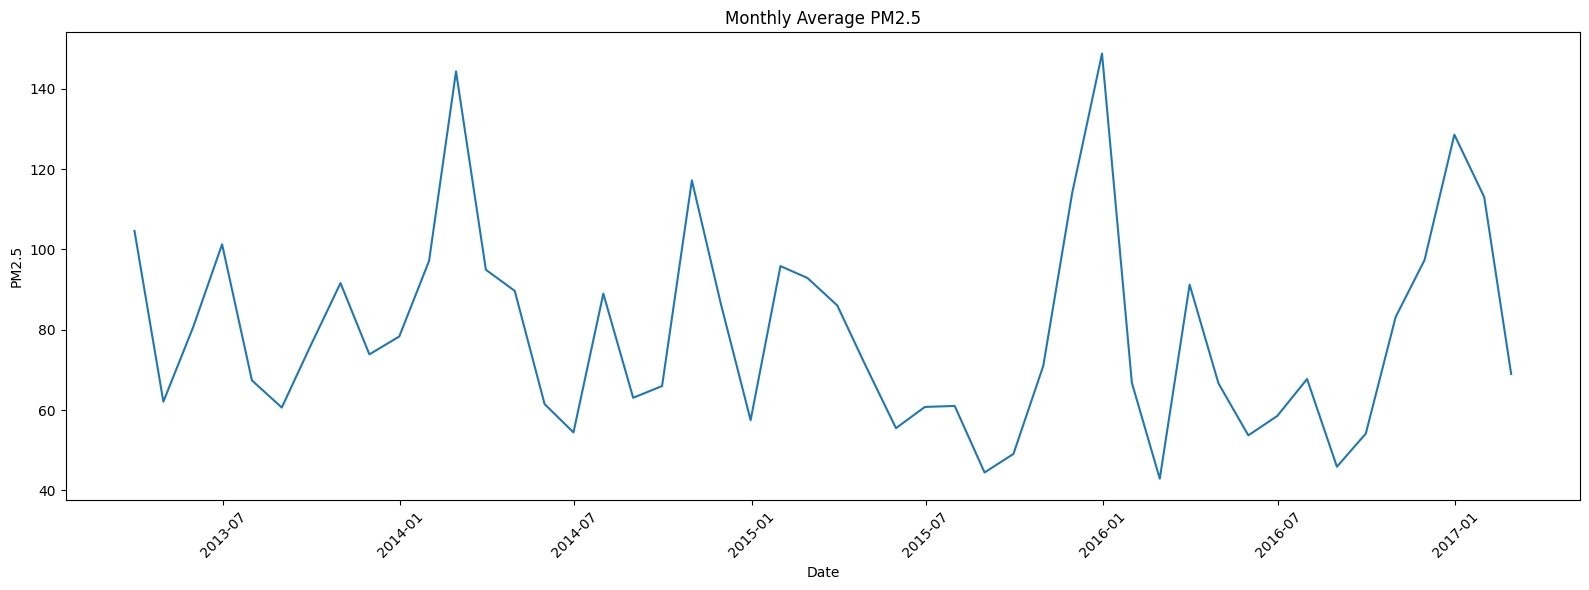

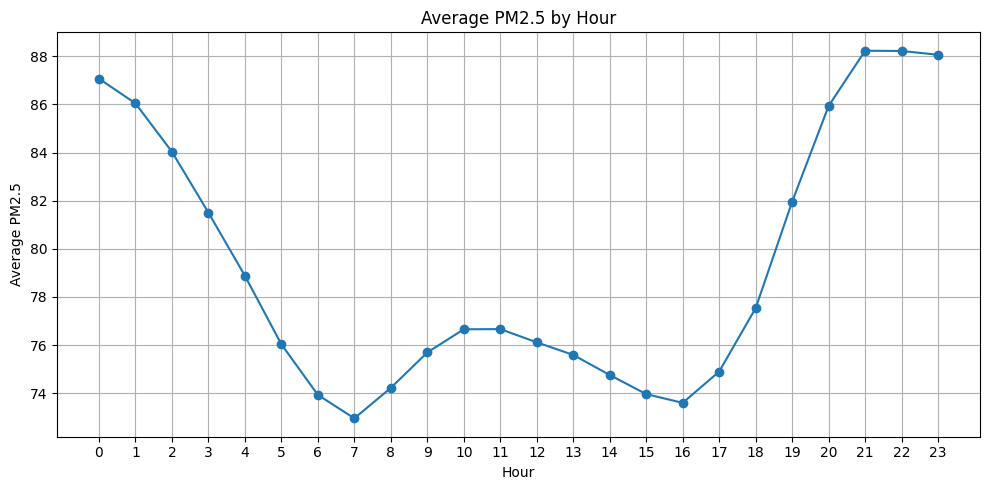

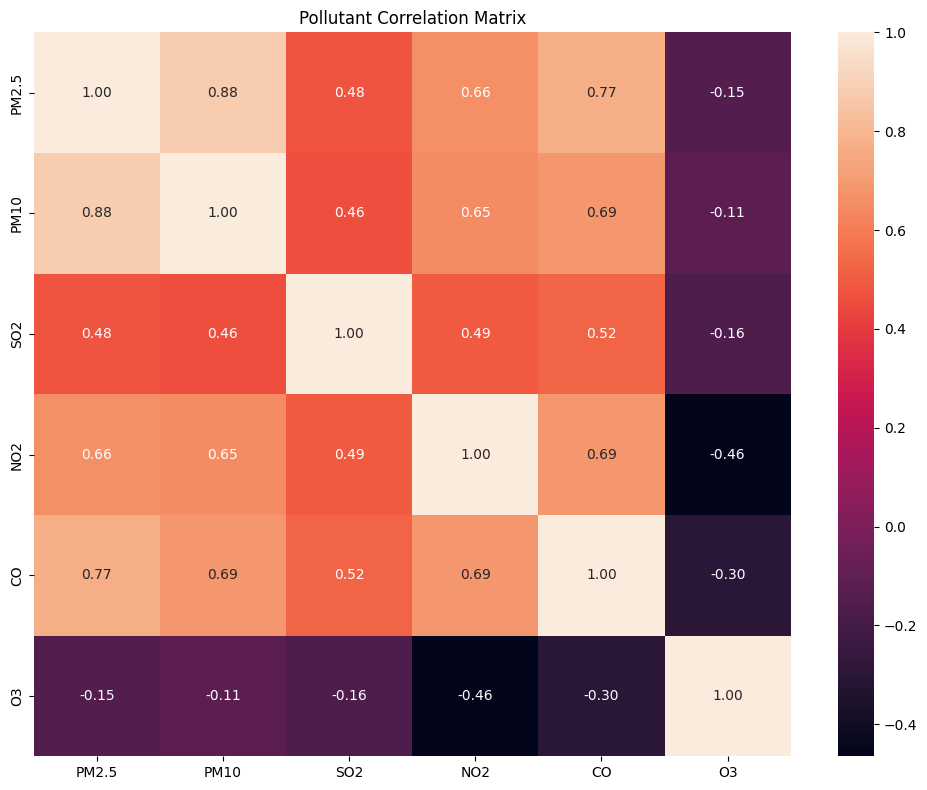

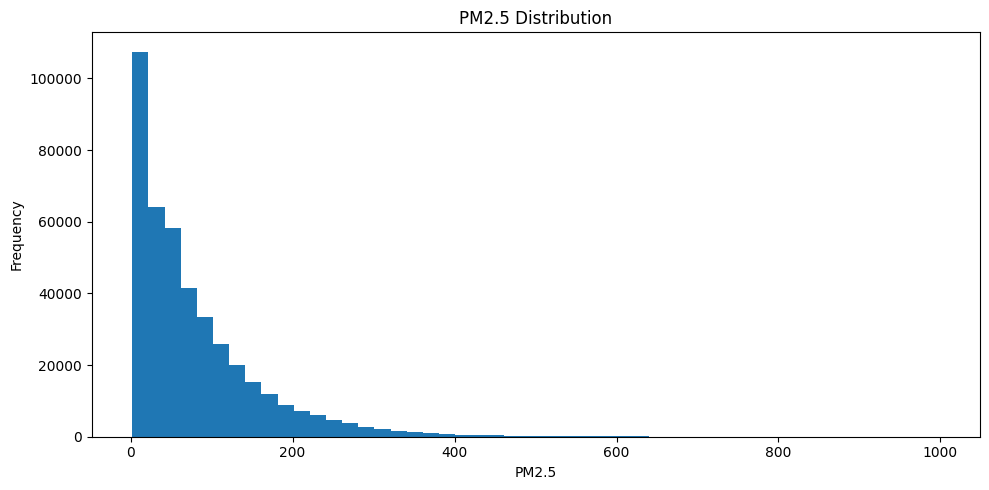


SUCCESS!
Clean dataset saved at:
/content/beijing_air_quality_cleaned.csv


In [15]:

# ------------------------------------------------------------
# BASIC INFORMATION
# ------------------------------------------------------------

print("\n" + "="*70)
print("DATASET OVERVIEW")
print("="*70)

print(
    "Rows:",
    df.shape[0]
)

print(
    "Columns:",
    df.shape[1]
)

print("\nColumns:")

print(
    df.columns.tolist()
)


# ------------------------------------------------------------
# FIRST FIVE ROWS
# ------------------------------------------------------------

print("\n" + "="*70)
print("FIRST FIVE ROWS")
print("="*70)

display(
    df.head()
)


# ------------------------------------------------------------
# DATA TYPES
# ------------------------------------------------------------

print("\n" + "="*70)
print("DATA TYPES")
print("="*70)

print(
    df.dtypes
)


# ------------------------------------------------------------
# DUPLICATES
# ------------------------------------------------------------

print("\n" + "="*70)
print("DUPLICATES")
print("="*70)

print(
    "Duplicate rows:",
    df.duplicated().sum()
)


# ------------------------------------------------------------
# MISSING VALUES
# ------------------------------------------------------------

print("\n" + "="*70)
print("MISSING VALUES")
print("="*70)

missing = (
    df.isnull()
    .sum()
    .sort_values(
        ascending=False
    )
)

print(
    missing[
        missing > 0
    ]
)


# ------------------------------------------------------------
# CREATE DATETIME
# ------------------------------------------------------------

df["datetime"] = pd.to_datetime(
    df[
        ["year", "month", "day", "hour"]
    ]
)


# ------------------------------------------------------------
# SORT DATA
# ------------------------------------------------------------

df = df.sort_values(
    [
        "station",
        "datetime"
    ]
).reset_index(
    drop=True
)


# ------------------------------------------------------------
# POLLUTANT COLUMNS
# ------------------------------------------------------------

pollutants = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3"
]


# ------------------------------------------------------------
# NUMERICAL COLUMNS
# ------------------------------------------------------------

numeric_columns = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3",
    "TEMP",
    "PRES",
    "DEWP",
    "RAIN",
    "WSPM"
]


# ------------------------------------------------------------
# CONVERT NUMERICAL DATA
# ------------------------------------------------------------

for column in numeric_columns:

    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )


# ------------------------------------------------------------
# IMPORTANT:
# DO NOT REMOVE ALL NEGATIVE VALUES
#
# TEMP and DEWP can legitimately be negative.
#
# Only pollutant concentrations and RAIN/WSPM
# should be checked for invalid negative readings.
# ------------------------------------------------------------

non_negative_columns = [
    "PM2.5",
    "PM10",
    "SO2",
    "NO2",
    "CO",
    "O3",
    "RAIN",
    "WSPM"
]


print("\n" + "="*70)
print("NEGATIVE VALUES")
print("="*70)

for column in non_negative_columns:

    count = (
        df[column] < 0
    ).sum()

    print(
        column,
        ":",
        count
    )


# ------------------------------------------------------------
# REPLACE INVALID NEGATIVE VALUES WITH NaN
# ------------------------------------------------------------

for column in non_negative_columns:

    df.loc[
        df[column] < 0,
        column
    ] = np.nan


# ------------------------------------------------------------
# FILL MISSING NUMERICAL VALUES
#
# First: station-wise median
# Second: overall median for anything remaining
# ------------------------------------------------------------

for column in numeric_columns:

    df[column] = (
        df.groupby(
            "station"
        )[column]
        .transform(
            lambda x:
            x.fillna(
                x.median()
            )
        )
    )

    df[column] = (
        df[column]
        .fillna(
            df[column].median()
        )
    )


# ------------------------------------------------------------
# FILL MISSING WIND DIRECTION
# ------------------------------------------------------------

df["wd"] = (
    df["wd"]
    .fillna(
        df["wd"].mode()[0]
    )
)


# ------------------------------------------------------------
# CREATE ADDITIONAL TIME FEATURES
# ------------------------------------------------------------

df["date"] = (
    df["datetime"]
    .dt.date
)

df["year_month"] = (
    df["datetime"]
    .dt.to_period("M")
    .astype(str)
)

df["hour"] = (
    df["datetime"]
    .dt.hour
)

df["day_of_week"] = (
    df["datetime"]
    .dt.day_name()
)


# ------------------------------------------------------------
# FINAL MISSING VALUE CHECK
# ------------------------------------------------------------

print("\n" + "="*70)
print("MISSING VALUES AFTER CLEANING")
print("="*70)

remaining_missing = (
    df.isnull()
    .sum()
)

print(
    remaining_missing[
        remaining_missing > 0
    ]
)


# ------------------------------------------------------------
# FINAL DATASET
# ------------------------------------------------------------

print("\n" + "="*70)
print("FINAL DATASET")
print("="*70)

print(
    "Rows:",
    df.shape[0]
)

print(
    "Columns:",
    df.shape[1]
)


# ------------------------------------------------------------
# STATION COUNT
# ------------------------------------------------------------

print("\nNumber of stations:")

print(
    df["station"].nunique()
)

print(
    df["station"].unique()
)


# ------------------------------------------------------------
# DATE RANGE
# ------------------------------------------------------------

print("\nDate range:")

print(
    df["datetime"].min()
)

print(
    df["datetime"].max()
)


# ------------------------------------------------------------
# AVERAGE POLLUTION BY STATION
# ------------------------------------------------------------

station_summary = (
    df.groupby(
        "station"
    )[pollutants]
    .mean()
    .round(2)
)

print("\n" + "="*70)
print("AVERAGE POLLUTION BY STATION")
print("="*70)

display(
    station_summary
)


# ------------------------------------------------------------
# MONTHLY PM2.5
# ------------------------------------------------------------

monthly_pm25 = (
    df.set_index(
        "datetime"
    )["PM2.5"]
    .resample("M")
    .mean()
    .reset_index()
)


plt.figure(
    figsize=(16, 6)
)

plt.plot(
    monthly_pm25["datetime"],
    monthly_pm25["PM2.5"]
)

plt.title(
    "Monthly Average PM2.5"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "PM2.5"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# HOURLY PM2.5
# ------------------------------------------------------------

hourly_pm25 = (
    df.groupby(
        "hour"
    )["PM2.5"]
    .mean()
)


plt.figure(
    figsize=(10, 5)
)

plt.plot(
    hourly_pm25.index,
    hourly_pm25.values,
    marker="o"
)

plt.title(
    "Average PM2.5 by Hour"
)

plt.xlabel(
    "Hour"
)

plt.ylabel(
    "Average PM2.5"
)

plt.xticks(
    range(24)
)

plt.grid(
    True
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# POLLUTANT CORRELATION
# ------------------------------------------------------------

correlation = (
    df[pollutants]
    .corr()
)


plt.figure(
    figsize=(10, 8)
)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Pollutant Correlation Matrix"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# PM2.5 DISTRIBUTION
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 5)
)

plt.hist(
    df["PM2.5"],
    bins=50
)

plt.title(
    "PM2.5 Distribution"
)

plt.xlabel(
    "PM2.5"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# SAVE CLEAN DATASET
# ------------------------------------------------------------

output_file = (
    "/content/"
    "beijing_air_quality_cleaned.csv"
)

df.to_csv(
    output_file,
    index=False
)


# ------------------------------------------------------------
# FINAL MESSAGE
# ------------------------------------------------------------

print("\n" + "="*70)

print(
    "SUCCESS!"
)

print(
    "Clean dataset saved at:"
)

print(
    output_file
)

print("="*70)

-rw-r--r-- 1 root root 0 Sep 20 05:25 /content/beijing_air_quality.zip
/content/beijing_air_quality.zip: empty
